# 04 · RFM analysis
* **R** = `Recency` (days since last purchase; lower = better) · **F** = web + catalog + store purchases · **M** = total 2-year spend.
* Quintile scores 1–5 via `rank(method='first')` so each bin has ~404 customers even though F has many ties.
* Business grid: recency terciles × value terciles of (F+M)/2 → 9 descriptive segments. Labels describe the scores; the profile table then checks what they mean.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4g}")
from src import pipeline as P
from src.config import *

[19:40:53] features + RFM


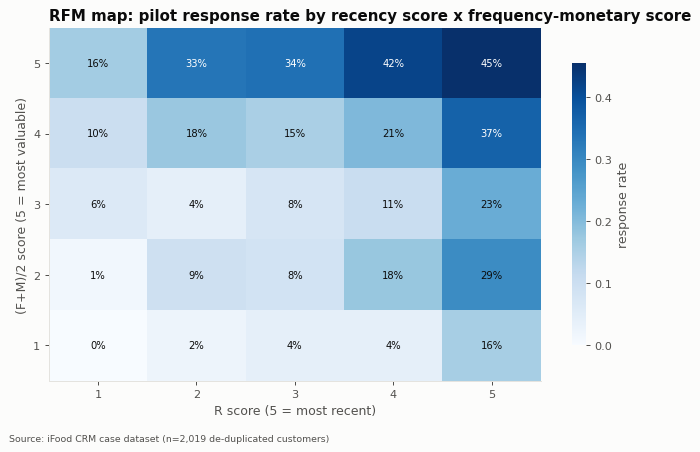

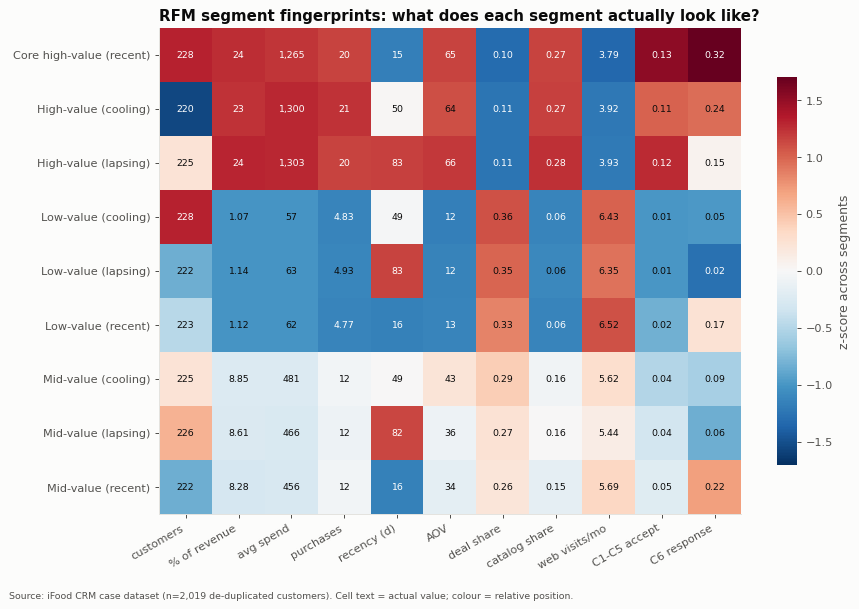

,score,recency_days,frequency,monetary
0,1,80-99,0-5,5-55
1,2,59-80,5-9,55-199
2,3,39-59,9-15,201-636
3,4,19-39,15-20,636-1173
4,5,0-19,20-32,1173-2524


In [2]:
ctx = P.prepare('stage_features')
ctx = P.stage_features(ctx)
import pandas as pd
pd.read_csv(TAB/'rfm_score_edges.csv')

**Edge cases:** tied frequencies at bin boundaries are split by row order (documented; affects ≤ a few customers per boundary); tier boundaries 32 and 66 days appear in two tiers for the same reason. No outlier trimming is needed — ranks are robust to the long spend tail.

In [3]:
ctx['rfm_profiles']

,customers,share_customers_pct,total_spend,share_revenue_pct,avg_spend,median_spend,avg_purchases,avg_recency_days,avg_aov,avg_web_visits,deals_share,catalog_share,prior5_accept_rate,pilot_response_rate,avg_income,avg_children
rfm_segment,,,,,,,,,,,,,,,,
Core high-value (recent),228,11.29,288319,23.57,"1,265","1,209",20.46,15.38,64.65,3.794,0.1,0.27,0.132,0.316,7.252e+04,0.465
High-value (cooling),220,10.9,285925,23.38,"1,300","1,248",21.02,49.93,63.57,3.923,0.107,0.271,0.107,0.241,7.113e+04,0.555
High-value (lapsing),225,11.14,293223,23.98,"1,303","1,264",20.48,82.96,65.82,3.933,0.107,0.278,0.12,0.151,7.166e+04,0.516
Low-value (cooling),228,11.29,13087,1.07,57.4,46,4.825,48.72,11.66,6.43,0.358,0.061,0.013,0.048,3.176e+04,1.268
Low-value (lapsing),222,11,13903,1.137,62.63,51,4.932,82.72,12.3,6.351,0.348,0.063,0.013,0.018,3.447e+04,1.32
Low-value (recent),223,11.04,13731,1.123,61.57,48,4.767,15.91,12.62,6.52,0.331,0.06,0.021,0.17,3.315e+04,1.215
Mid-value (cooling),225,11.14,108248,8.851,481.1,405,12.18,49.48,43.4,5.622,0.286,0.159,0.036,0.089,5.175e+04,1.142
Mid-value (lapsing),226,11.19,105350,8.614,466.1,377.5,11.93,82.29,36.3,5.442,0.267,0.164,0.045,0.062,5.068e+04,1.053
Mid-value (recent),222,11,101224,8.277,456,394,12.22,16,34.34,5.694,0.263,0.15,0.05,0.216,5.111e+04,1.018


In [4]:
print(ctx['rfm_test'])

{'chi2': np.float64(144.14179621341046), 'dof': 8, 'p_value': np.float64(3.260880647791057e-27), 'cramers_v': 0.2671940638617504, 'n': 2019}


> **Finding:** Only 'Core high-value (recent)' would have been profitable in the pilot on its own (31.6 % response vs 27.3 % break-even; +108 MU). 'High-value (lapsing)' customers — same spend as the core group — responded at only 15.1 %.
>
> **Business implication:** Value alone does not justify a paid offer; recency within high value strongly separates response in this pilot.
>
> **Recommended action:** Use RFM as the interpretable segmentation layer; do not use it as the only targeting score (campaign history beats it, notebook 07).
>
> **Evidence:** Segment profiles, pilot economics by segment (notebook 06), χ² = 144, V = 0.27.
>
> **Assumption:** Segment differences in the pilot reflect stable behaviour.
>
> **Limitation:** The pilot recency gradient is not present in C1–C5 (possible timing artefact, see leakage audit).